# SMACNP Training — Combined ERA5 + PeakWeather Context

Trains a Sparse Multi-head Attention Convolutional Neural Process (SMACNP) for
daily mean temperature downscaling over Switzerland, using a **combined context**
of ERA5 reanalysis grid cells and PeakWeather station observations.

## Context and target

- **Context (what the model sees each day)**:
  ERA5 reanalysis grid (~1769 cells at ~25 km resolution) **plus** the 60 % of
  PeakWeather stations assigned to the training split (~103 stations).
  A source flag (7th feature: 0 = ERA5, 1 = PW station) lets the model learn
  to weight high-fidelity station measurements more heavily than coarse
  reanalysis estimates.
- **Validation target**: the 20 % of PeakWeather stations assigned to the
  validation split (~34 stations), using their raw PW observations as ground
  truth (no MeteoSwiss data needed).
- **Test target** (evaluated in the prediction notebook): the remaining 20 %
  of PeakWeather stations (~35 stations), never seen during training.

## Cross-validation

5-fold cross-validation over time. Each fold holds out a contiguous fifth of
the common ERA5–PW date range. The model is re-initialised
and retrained from scratch for each fold.

## Normalisation

Both ERA5 and PW temperatures are normalised using the same ERA5 statistics
(mean and std computed over the ERA5 domain), so all context temperatures are
on a consistent scale. The saved `metadata.json` contains these statistics for
use in the prediction notebook.


In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

/home/renku/work/convNPClimate/params.py:98: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert (not (not self.SEASONAL_FEATURES and self.SEASONAL_FEATURES_IN_MLP),


Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
TEMPERATURE_TYPE = 'mean'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE  = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

PARAMS = params.Params(
    VARIABLE='tmax',
    TEMPERATURE_TYPE=TEMPERATURE_TYPE,
    MODEL_TYPE='smacnp',
    CONTEXT_TYPE='combined',
    LOSS_FN='gll',
    PW_TRAIN_FRAC=0.8,
    PW_VAL_FRAC=0.0,
    STATION_SPLIT_SEED=42,
    N_EPOCHS=30,
    PATIENCE=20,
    N_FOLDS=1,
    TRIAL_NAME='test-combined-era5-pw-mean-11',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=True,
    # SMACNP architecture
    R_DIM=128,
    W_DIM=64,
    V_DIM=256,
    N_HEADS=16,
    SMACNP_HIDDEN=512,
    NUM_LAYERS_MLP=2,
    USE_PE=False,
    PE_DIM=32,
    DROPOUT_RATE=0.1,
    LR=4.93e-4,
    USE_LAYER_NORM=False,
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, TEMPERATURE_TYPE='mean', SEASONAL_FEATURES=True, SEASONAL_FEATURES_IN_MLP=True, USE_ELEVATION=True, USE_MTPI=True, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, N_EPOCHS=30, BATCH_SIZE=8, LR=0.000493, PATIENCE=20, LOSS_FN='gll', N_FOLDS=1, SEED=42, TRIAL_NAME='test-combined-era5-pw-mean-11', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, ERA5_MEAN_TEMP_GLOB=None, METEO_SWISS_MEAN_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None, MODEL_TYPE='smacnp', R_DIM=128, W_DIM=64, V_DIM=256, N_HEADS=16, SMACNP_HIDDEN=512, NUM_LAYERS_MLP=2, USE_PE=False, PE_DIM=32, DROPOUT_RATE=0.1, LAPLACE_P=1.0, USE_LAYER_NORM=False, PW_TRAIN_FRAC=0.8, PW_VAL_FRAC=0.0, STATION_SPLIT_SEED=42, CONTEXT_TYPE='combined')


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_smacnp

/home/renku/work/.venv/lib/python3.13/site-packages/dirsync/syncer.py:104: SyntaxWarning: invalid escape sequence '\.'
  self._exclude.append('^\.dirsync$')


In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

# Note: loading datasets on Renkulab directly from Polybox was no working well.
# Things do work if we first sync the files over to local storage and then load them
# locally.
cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:


dirsync finished in 2.17 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [6]:
if TEMPERATURE_TYPE == 'max':
    _era5_glob = PARAMS.ERA5_MAX_TEMP_GLOB
    _era5_var  = 't2m_max'
else:
    _era5_glob = PARAMS.ERA5_MEAN_TEMP_GLOB
    _era5_var  = 't2m'

era5_tensor, era5_metadata, era5_grid_elevation, time_coords_era5 = ds.load_era5_data(
    _era5_glob,
    var_name=_era5_var,
    year_start=None,            
    geopotential_glob=PARAMS.ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    include_seasonal_embeddings=PARAMS.SEASONAL_FEATURES,
    device=device,
)
era5_dates_pd = pd.DatetimeIndex(pd.to_datetime(time_coords_era5).date.astype(str))
x_era5, y_era5 = ds.build_smacnp_context(era5_tensor)
print(f"ERA5 context: x_era5={x_era5.shape}, y_era5={y_era5.shape}")
print(f"ERA5 date range: {era5_dates_pd[0]} → {era5_dates_pd[-1]}")
# era5_tensor: (T_era5, 6, 29, 61)
# x_era5: (T_era5, 1769, 6)
# y_era5: (T_era5, 1769, 1)

Loading ERA5 data from: datasets/ERA5_Land/temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([23376, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 grid points are subset of geopotential grid (using near

In [7]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)
tpi_abs_max = float(max(
    abs(float(hi_res_tpi.min())), 
    abs(float(hi_res_tpi.max()))
))
print(f"TPI abs max: {tpi_abs_max:.1f} m")


Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32
TPI abs max: 408.0 m


In [8]:
# Load PeakWeather stations (all valid stations, before split)
daily_tmean_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)
daily_tmean_pw.index = daily_tmean_pw.index - pd.Timedelta(days=1)
pw_dates_pd = pd.DatetimeIndex(daily_tmean_pw.index.date.astype(str))

# Seasonal features from PW time axis
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if PARAMS.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}")
else:
    seasonal_features = None


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...
  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Seasonal features shape: torch.Size([2921, 2])


In [9]:
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=PARAMS.PW_TRAIN_FRAC,
    val_frac=PARAMS.PW_VAL_FRAC,
    seed=PARAMS.STATION_SPLIT_SEED,
)

# Compute normalization stats from train stations only
pw_metadata = ds.compute_pw_metadata(daily_tmean_pw, train_stations)
print(f"PW metadata: mean={pw_metadata.data_mean:.2f} K, std={pw_metadata.data_std:.2f} K")


Station split: 137 train / 0 val / 35 test
PW train stats: mean=280.93 K, std=8.07 K
PW metadata: mean=280.93 K, std=8.07 K


In [10]:
# Both ERA5 and PW must cover the same dates for combined context.
# Take the intersection: typically 2017-01-01 → 2023-12-31
common_dates = pw_dates_pd.intersection(era5_dates_pd)
print(f"PW dates:      {len(pw_dates_pd)} ({pw_dates_pd[0]} → {pw_dates_pd[-1]})")
print(f"ERA5 dates:    {len(era5_dates_pd)} ({era5_dates_pd[0]} → {era5_dates_pd[-1]})")
print(f"Common dates:  {len(common_dates)} ({common_dates[0]} → {common_dates[-1]})")

# Index arrays to slice each source to the common date range
era5_idx = np.array([era5_dates_pd.get_loc(d) for d in common_dates])
pw_idx   = np.array([pw_dates_pd.get_loc(d)   for d in common_dates])

# Slice ERA5 context to common dates
x_era5_aligned = x_era5[era5_idx]                           # (T_common, 1769, 6)
y_era5_aligned = y_era5[era5_idx]                           # (T_common, 1769, 1)

y_era5_aligned = y_era5_aligned * era5_metadata.data_std + era5_metadata.data_mean  # → Kelvin
y_era5_aligned = (y_era5_aligned - pw_metadata.data_mean) / pw_metadata.data_std    # → PW scale

# Slice seasonal features to common dates (they follow PW time axis)
seasonal_features_aligned = seasonal_features[pw_idx]       # (T_common, 2)
T_common = len(common_dates)

PW dates:      2921 (2016-12-31 00:00:00 → 2024-12-29 00:00:00)
ERA5 dates:    23376 (1960-01-01 00:00:00 → 2023-12-31 00:00:00)
Common dates:  2557 (2016-12-31 00:00:00 → 2023-12-31 00:00:00)


In [11]:
x_pw_train, y_pw_train = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean_pw,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=pw_metadata,
    seasonal_features=seasonal_features_aligned,
    dates_pd=common_dates,
    device=device,
)
y_pw_train = y_pw_train.unsqueeze(-1)
print(f"PW train context: x={x_pw_train.shape}, y={y_pw_train.shape}")
# x_pw_train: (T_common, 103, 6)
# y_pw_train: (T_common, 103, 1)

PW train context: x=torch.Size([2557, 137, 6]), y=torch.Size([2557, 137, 1])


In [12]:
params.set_seed(PARAMS.SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

# Save era5_metadata — prediction notebook will reload this for consistent normalization
PARAMS.save_json(OUTPUT_DIR / 'params.json')
ds.save_metadata_json(pw_metadata, OUTPUT_DIR / 'metadata.json')

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

for fold in range(PARAMS.N_FOLDS):
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    params.set_seed(PARAMS.SEED + fold)

    model, loss_fn, get_value_fn = model_factory.build_smacnp(
        PARAMS,
        input_dim=x_pw_train.shape[-1],
        context_input_dim=x_pw_train.shape[-1] + 1
    )
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    train_smacnp(
        model=model, opt=optimizer, ll=loss_fn,
        x_era5=x_era5_aligned, y_era5=y_era5_aligned,
        x_pw=x_pw_train,       y_pw=y_pw_train,
        output_dir=OUTPUT_DIR, get_value=get_value_fn,
        fold=fold, n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS, batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE, stats_file=fold_stats_file,
        device=device,
        npsplit_fraction=(0.2, 0.8),
        val_context_fraction=0.5,
        use_temporal_split=False,
        npsplit_inclusive=True,        # True: target = all stations, False: target is exclusive of context
    )
    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)



Starting fold 1/1...

Built SMACNP with 3,179,459 trainable parameters
Fold 1/1 | Epoch 0 | train NLL 0.050 | test NLL -0.035 | med MAE 0.183 | elapsed 49s | est. remaining 1417s
Fold 1/1 | Epoch 1 | train NLL -0.129 | test NLL -0.219 | med MAE 0.151 | elapsed 92s | est. remaining 1288s
Fold 1/1 | Epoch 2 | train NLL -0.312 | test NLL -0.310 | med MAE 0.141 | elapsed 135s | est. remaining 1216s
Fold 1/1 | Epoch 3 | train NLL -0.243 | test NLL -0.281 | med MAE 0.144 | elapsed 179s | est. remaining 1158s
Fold 1/1 | Epoch 4 | train NLL -0.399 | test NLL -0.389 | med MAE 0.128 | elapsed 222s | est. remaining 1107s
Fold 1/1 | Epoch 5 | train NLL -0.395 | test NLL -0.391 | med MAE 0.130 | elapsed 265s | est. remaining 1058s
Fold 1/1 | Epoch 6 | train NLL -0.405 | test NLL -0.339 | med MAE 0.136 | elapsed 309s | est. remaining 1011s
Fold 1/1 | Epoch 7 | train NLL -0.363 | test NLL -0.436 | med MAE 0.123 | elapsed 352s | est. remaining 964s
Fold 1/1 | Epoch 8 | train NLL -0.382 | test NLL -0.

In [13]:
OUTPUT_DIR
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

In [14]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/test-combined-era5-pw-mean-11/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.183339,NaN,NaN,0,0.050187,-0.034618
1,0,0.150670,NaN,NaN,1,-0.128714,-0.218848
2,0,0.141351,NaN,NaN,2,-0.311864,-0.310384
3,0,0.143709,NaN,NaN,3,-0.242889,-0.280706
4,0,0.128364,NaN,NaN,4,-0.398670,-0.388564
5,0,0.129659,NaN,NaN,5,-0.394706,-0.391340
6,0,0.136245,NaN,NaN,6,-0.405371,-0.339231
7,0,0.123095,NaN,NaN,7,-0.363148,-0.435719
8,0,0.120695,NaN,NaN,8,-0.381530,-0.456552
9,0,0.117601,NaN,NaN,9,-0.401528,-0.482427


  Saved plot: trained_models/test-combined-era5-pw-mean-11/trainingstats_fold0


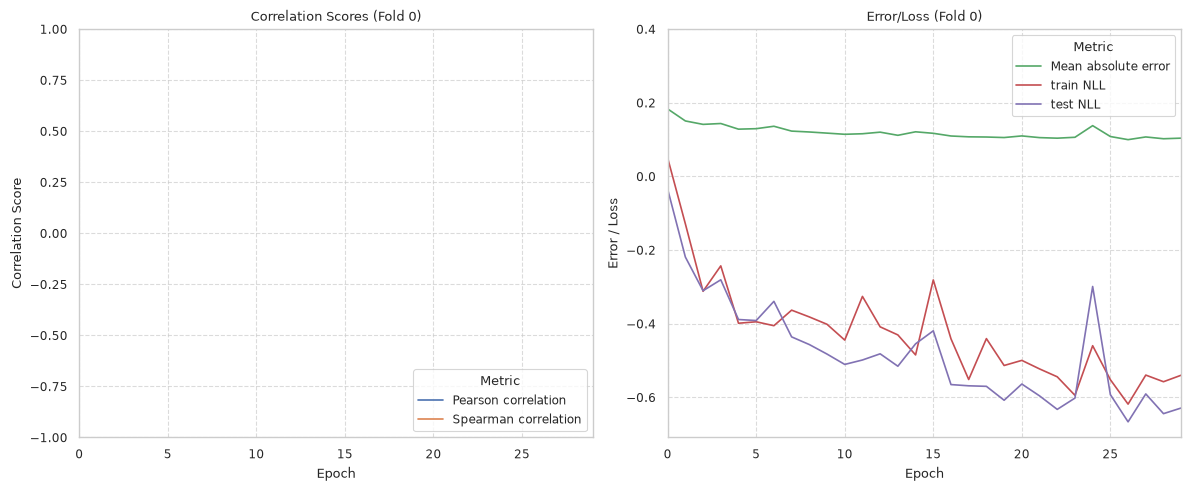

  Saved plot: trained_models/test-combined-era5-pw-mean-11/trainingstats_all


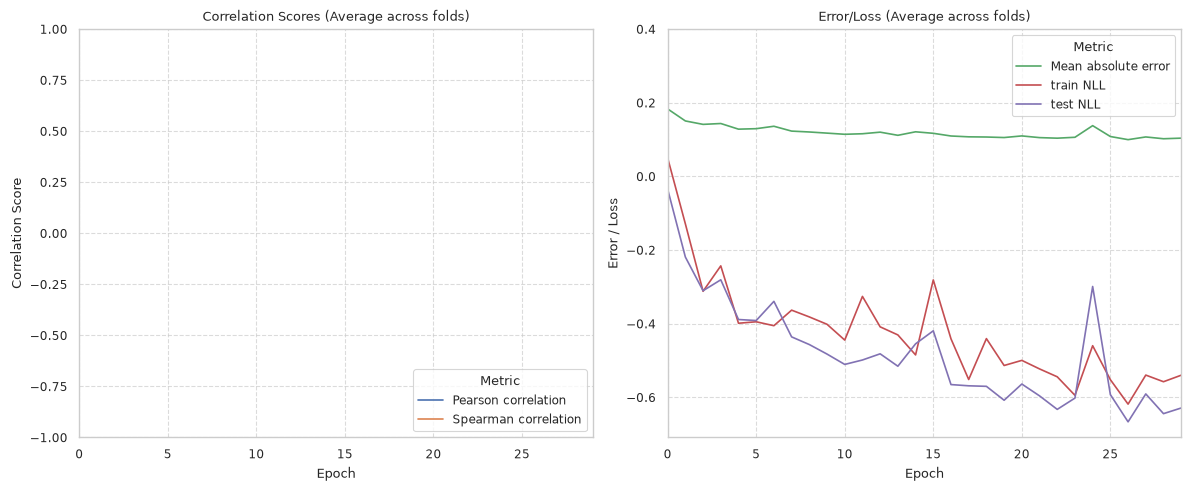

In [15]:
save_path_prefix = str(OUTPUT_DIR / 'trainingstats')
vis.plot_training_curves(stats, save_path=save_path_prefix)
plt.show()